# GFB Species Assignment Map
## Gary Ding &nbsp;&nbsp;&nbsp; March 3rd, 2026
Assigns top 5 native plant species to 1 km road segments based on coverage-weighted species distribution overlap and combined scores.

**Scoring:** `Segment Score = C × Range Weight × Coverage Fraction`

**Inputs:** road shapefile, study area boundary, 5 species shapefiles, scored xlsx

**Outputs:** `road_segments.shp`, `road_segments_scored.shp`, inline matplotlib maps

---

In [1]:
# Cell 1 - Install
!pip install -q geopandas shapely openpyxl mapclassify matplotlib
print('Ready.')

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Ready.


In [7]:
# Cell 2 - Configuration

SEGMENT_LENGTH_M = 1000
BUFFER_M = 15

SPECIES_FILES = {
    "ʻAʻaliʻi":       "dodvisc",
    "Naio":            "myosand",
    # "Milo":            "thepopu",
    "Naupaka kahakai": "scatacc",
    # "Koa":         "acakoa",
    "Alaheʻe": "psyodor",
    "ʻUhaloa": "walindi"
}

RANGE_TYPE_FIELD = "GRIDCODE"
WEIGHT_ESTIMATED = 1.0  # GRIDCODE 2
WEIGHT_POSSIBLE  = 0.5  # GRIDCODE 1

MAJOR_CLASSES = ["A31", "A35"]

ROAD_SHAPEFILE     = "Roads_-_Hawaii_County.shp"
BOUNDARY_SHAPEFILE = "nksk.shp"     # study area boundary
SCORES_FILE        = "gonative_combined_scored_3_5.xlsx"
SCORES_SHEET       = "Combined Results"

SPECIES_COLORS = {
    "ʻAʻaliʻi":       "#2E7D32",
    "Naio":            "#1565C0",
    # "Milo":            "#EF6C00",
    "Alaheʻe":            "#EF6C00",
    "Naupaka kahakai": "#00838F",
    #"Koa":             "#AD1457",
    "ʻUhaloa":             "#AD1457"
}
NO_SPECIES_COLOR = "#9E9E9E"

SDM_DEFAULT_CRS = "EPSG:26904"
PROJECTED_CRS   = "EPSG:32605"
OUTPUT_CRS      = "EPSG:4326"

print(f"Config: {len(SPECIES_FILES)} species, {SEGMENT_LENGTH_M} m segments, {BUFFER_M} m buffer")
print(f"Road filter: {MAJOR_CLASSES}")


Config: 5 species, 1000 m segments, 15 m buffer
Road filter: ['A31', 'A35']


In [9]:
# # Cell 3 - Upload Files
# from google.colab import files
# import os, glob, zipfile

# print("Upload all files (.shp+.shx+.dbf+.prj, xlsx). Zips auto-extract.")
# uploaded = files.upload()

# for f in list(uploaded.keys()):
#     if f.endswith(".zip"):
#         with zipfile.ZipFile(f, "r") as z:
#             z.extractall(".")
#             print(f"  Extracted {f}")

# print(f"\nShapefiles: {sorted(glob.glob('*.shp'))}")

# # Cell 3 - Set File Paths (Jupyter Notebook)
# import os, glob, zipfile

# # Point to the folder containing all your shapefiles and xlsx
# DATA_DIR = "/Users/garyding/Desktop/gbf_top10"  # <-- change this

# os.chdir(DATA_DIR)

# # Auto-extract any zips
# for f in glob.glob("*.zip"):
#     with zipfile.ZipFile(f, "r") as z:
#         z.extractall(".")
#         print(f"  Extracted {f}")

# print(f"Working directory: {os.getcwd()}")
# print(f"Shapefiles: {sorted(glob.glob('*.shp'))}")

# Cell 3 - Set File Paths (Jupyter Notebook)
import os, glob

DATA_DIR = "/Users/garyding/Desktop/gbf_top10"  
os.chdir(DATA_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Shapefiles: {sorted(glob.glob('*.shp'))}")

Working directory: /Users/garyding/Desktop/gbf_top10
Shapefiles: ['Roads_-_Hawaii_County.shp', 'acakoa.shp', 'dodvisc.shp', 'myosand.shp', 'nksk.shp', 'psyodor.shp', 'road_segments.shp', 'road_segments_scored.shp', 'scatacc.shp', 'thepopu.shp', 'walindi.shp']


In [10]:
# Cell 4 - Clip, Filter Major Roads, Segment

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.ops import substring
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

def norm(s):
    s = str(s).strip()
    for ch in "\u02bb\u2018\u2019\u0060\u00b4\u0027":
        s = s.replace(ch, "\u02bb")
    return s

def safe_load(path, default_crs=None, target_crs=None):
    if default_crs is None: default_crs = SDM_DEFAULT_CRS
    if target_crs is None: target_crs = PROJECTED_CRS
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        print(f"    No CRS for {path}, assigning {default_crs}")
        gdf = gdf.set_crs(default_crs)
    try:
        gdf = gdf.to_crs(target_crs)
    except Exception as e:
        print(f"    CRS reproject failed for {path}, forcing {default_crs}")
        gdf = gdf.set_crs(default_crs, allow_override=True)
        gdf = gdf.to_crs(target_crs)
    return gdf

# 1. Load and clip
print("Loading roads...")
roads = gpd.read_file(ROAD_SHAPEFILE)
boundary = gpd.read_file(BOUNDARY_SHAPEFILE)
print(f"  Roads CRS: {roads.crs}  |  {len(roads)} features")
print(f"  Boundary CRS: {boundary.crs}")

if roads.crs is None: roads = roads.set_crs(SDM_DEFAULT_CRS)
if boundary.crs is None: boundary = boundary.set_crs(SDM_DEFAULT_CRS)
roads_utm = roads.to_crs(PROJECTED_CRS)
boundary_utm = boundary.to_crs(PROJECTED_CRS)
roads_clipped = gpd.clip(roads_utm, boundary_utm)
roads_all_clipped = roads_clipped.copy()  # keep full set before class filter
print(f"  After clipping: {len(roads_clipped)} features")

# 2. Filter to major roads
class_col = None
for col in roads_clipped.columns:
    if col.lower().rstrip("_") in ["class", "cls", "road_class", "fclass", "mtfcc"]:
        class_col = col; break

if class_col:
    print(f"\n  Road classes (column: {class_col}):")
    for cls, cnt in roads_clipped[class_col].value_counts().items():
        marker = " <-- KEEP" if cls in MAJOR_CLASSES else ""
        print(f"    {cls}: {cnt}{marker}")
    roads_clipped = roads_clipped[roads_clipped[class_col].isin(MAJOR_CLASSES)]
    print(f"  After filtering to {MAJOR_CLASSES}: {len(roads_clipped)} features")
else:
    print(f"  WARNING: no class column found in: {list(roads_clipped.columns)}")

# Also keep Waikoloa Rd by name
if "fullname" in roads_all_clipped.columns:
    extra = roads_all_clipped[roads_all_clipped["fullname"] == "WAIKOLOA RD"]
    if len(extra) > 0:
        roads_clipped = pd.concat([roads_clipped, extra]).drop_duplicates()
        print(f"  Added {len(extra)} features for WAIKOLOA RD")
        print(f"  Total: {len(roads_clipped)} features")

# 3. Segment
print(f"\nSegmenting into {SEGMENT_LENGTH_M} m units...")

def segment_line(geom, length):
    if geom.is_empty: return []
    if geom.geom_type == "MultiLineString":
        return [s for part in geom.geoms for s in segment_line(part, length)]
    total = geom.length
    if total <= length: return [geom]
    segs, start = [], 0
    while start < total:
        seg = substring(geom, start, min(start + length, total))
        if not seg.is_empty and seg.length > 0: segs.append(seg)
        start += length
    return segs

name_cols = ["NAME", "Name", "name", "STREET", "FULLNAME", "ROAD_NAME", "rd_name"]
seg_rows, sid = [], 1
for _, row in roads_clipped.iterrows():
    rn = next((str(row[c]) for c in name_cols
               if c in roads_clipped.columns and pd.notna(row.get(c))), "Unknown")
    for s in segment_line(row.geometry, SEGMENT_LENGTH_M):
        seg_rows.append({"seg_id": f"SEG_{sid:04d}", "road_name": rn,
                         "length_m": round(s.length, 1), "geometry": s})
        sid += 1

segments = gpd.GeoDataFrame(seg_rows, crs=PROJECTED_CRS)
print(f"  {len(segments)} segments (mean {segments.length_m.mean():.0f} m)")
print(f"\n  Roads in segments:")
for rn, cnt in segments.road_name.value_counts().items():
    print(f"    {rn}: {cnt} segments")

corridors = segments.copy()
corridors["geometry"] = segments.geometry.buffer(BUFFER_M, cap_style=2)
corridors["corridor_area"] = corridors.geometry.area

segments.to_file("road_segments.shp")
print("\nSaved road_segments.shp")


Loading roads...
  Roads CRS: EPSG:3750  |  13821 features
  Boundary CRS: EPSG:4326
  After clipping: 1201 features

  Road classes (column: class):
    Q02: 602
    A41: 374
    A31: 125 <-- KEEP
    Q01: 93
    A51: 5
    Q03: 2
  After filtering to ['A31', 'A35']: 125 features
  Added 13 features for WAIKOLOA RD
  Total: 138 features

Segmenting into 1000 m units...
  280 segments (mean 707 m)

  Roads in segments:
    QUEEN KAAHUMANU: 50 segments
    HAWAII BELT: 45 segments
    KAWAIHAE: 39 segments
    DANIEL K INOUYE: 38 segments
    MAMALAHOA: 38 segments
    WAIKOLOA: 27 segments
    SADDLE: 21 segments
    KOHALA MOUNTAIN: 16 segments
    AKONI PULE: 5 segments
    KE ALA KOA: 1 segments

Saved road_segments.shp


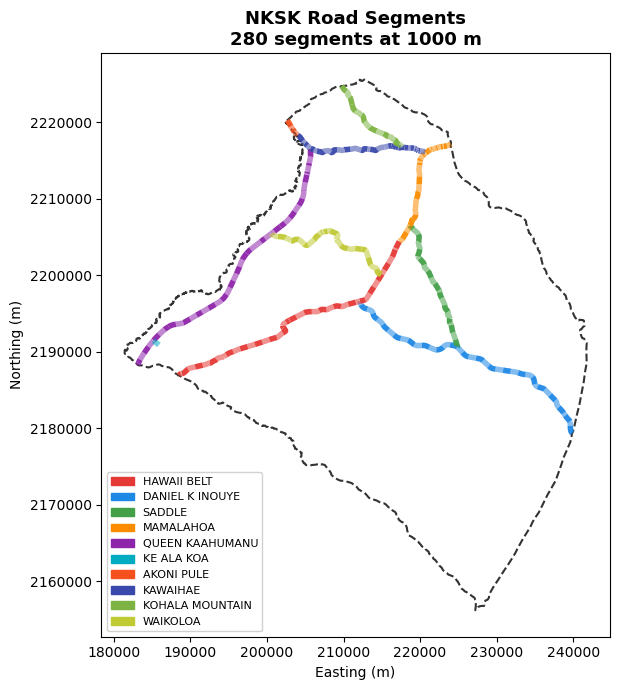

In [11]:
# Cell 5 - Plot Road Segments

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.5, linestyle="--")

road_names = segments.road_name.unique()
road_palette = ["#E53935","#1E88E5","#43A047","#FB8C00","#8E24AA",
                "#00ACC1","#F4511E","#3949AB","#7CB342","#C0CA33"]
road_colors = {n: road_palette[i % len(road_palette)] for i, n in enumerate(road_names)}

# Plot each segment individually with alternating shade
for i, (_, row) in enumerate(segments.iterrows()):
    color = road_colors.get(row["road_name"], "#666")
    alpha = 0.95 if i % 2 == 0 else 0.55
    geom = row.geometry
    parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
    for part in parts:
        xs, ys = part.xy
        ax.plot(xs, ys, color=color, linewidth=4, alpha=alpha, solid_capstyle="butt")

    # Label every segment
#     pt = row.geometry.interpolate(0.5, normalized=True)
#     ax.annotate(row["seg_id"], xy=(pt.x, pt.y), fontsize=4.5,
#                 ha="center", va="bottom", color="#333",
#                 bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

# Manual legend
legend_handles = [mpatches.Patch(color=road_colors[rn], label=rn) for rn in road_names]
ax.set_title(f"NKSK Road Segments\n{len(segments)} segments at {SEGMENT_LENGTH_M} m",
             fontsize=13, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower left", fontsize=8, framealpha=0.9)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("nksk_road_segments.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [12]:
# Cell 6 - Diagnostics

print("=== CRS Check ===")
print(f"Roads:    {roads.crs}")
print(f"Boundary: {boundary.crs}")
for name, base in SPECIES_FILES.items():
    path = f"{base}.shp"
    if os.path.exists(path):
        tmp = gpd.read_file(path)
        print(f"  {name:20s} CRS: {tmp.crs}")
    else:
        print(f"  {name:20s} NOT FOUND: {path}")

print(f"\n=== Bounds (UTM) ===")
print(f"Corridors: {corridors.total_bounds}")
for name, base in SPECIES_FILES.items():
    path = f"{base}.shp"
    if os.path.exists(path):
        tmp = safe_load(path)
        print(f"  {name:20s} {tmp.total_bounds}")

print(f"\n=== Overlap Test ===")
corr_union = corridors.geometry.unary_union
for name, base in SPECIES_FILES.items():
    path = f"{base}.shp"
    if os.path.exists(path):
        tmp = safe_load(path)
        n_int = sum(tmp.geometry.intersects(corr_union))
        print(f"  {name:20s} {n_int}/{len(tmp)} polygons overlap corridors")


=== CRS Check ===
Roads:    EPSG:3750
Boundary: EPSG:4326
  ʻAʻaliʻi             CRS: None
  Naio                 CRS: None
  Naupaka kahakai      CRS: None
  Alaheʻe              CRS: COMPD_CS["NAD83 / UTM zone 4N + Unknown VCS from ArcInfo Workstation",PROJCS["NAD83 / UTM zone 4N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-159],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["Unknown VCS from ArcInfo Workstation",VERT_DATUM["Unknown",2005],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP]]]
  ʻUhaloa              CRS: None

=== Bounds (UTM) ===
Corridors: [ 183099.4494

In [19]:
# Cell 7 - Coverage-Weighted Species Scoring

scores_df = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
name_col = [c for c in scores_df.columns if "Hawaiian" in str(c) or "hawaiian" in str(c)][0]
score_col = [c for c in scores_df.columns if "Combined" in str(c) or "combined" in str(c)][0]

scores_df["_norm"] = scores_df[name_col].apply(norm)
score_lookup = dict(zip(scores_df["_norm"], scores_df[score_col]))

print("=== Score Matching Check ===")
for species_name in SPECIES_FILES.keys():
    n = norm(species_name)
    c_val = score_lookup.get(n, "NOT FOUND")
    match = "OK" if c_val != "NOT FOUND" else "MISSING"
    print(f"  {species_name:20s} -> C = {c_val}  [{match}]")

missing = [sp for sp in SPECIES_FILES.keys() if score_lookup.get(norm(sp)) is None]
if missing:
    print(f"\n  WARNING: {len(missing)} species not matched!")
    print(f"  Spreadsheet names: {list(scores_df[name_col].head(15))}")

print(f"\n=== Coverage-Weighted Scoring ===")
print(f"Formula: SegmentScore = C x RangeWeight x CoverageFraction\n")
results = {row["seg_id"]: {} for _, row in segments.iterrows()}

for species_name, shp_base in SPECIES_FILES.items():
    shp_path = f"{shp_base}.shp"
    if not os.path.exists(shp_path):
        print(f"  WARNING: {shp_path} not found, skipping")
        continue

    sp = safe_load(shp_path)

    rt_field = None
    for col in sp.columns:
        if col.lower() == RANGE_TYPE_FIELD.lower():
            rt_field = col; break

    if rt_field:
        sp["_rw"] = sp[rt_field].apply(
            lambda x: WEIGHT_ESTIMATED if x == 2
            else WEIGHT_POSSIBLE if x == 1
            else WEIGHT_ESTIMATED)
        gc_counts = sp[rt_field].value_counts().to_dict()
    else:
        sp["_rw"] = WEIGHT_ESTIMATED
        gc_counts = "(no GRIDCODE)"

    C = score_lookup.get(norm(species_name), 0)
    n_hit = 0

    for ci, cr in corridors.iterrows():
        cands = sp[sp.geometry.intersects(cr["geometry"])]
        if len(cands) == 0: continue
        merged = cands.geometry.unary_union
        inter = cr["geometry"].intersection(merged)
        if inter.is_empty: continue
        frac = min(inter.area / cr["corridor_area"], 1.0)
        rw = cands["_rw"].max()
        score = round(C * rw * frac, 2)
        if score > 0:
            results[cr["seg_id"]][species_name] = {
                "score": score, "coverage": round(frac, 4), "range_weight": rw}
            n_hit += 1

    print(f"  {species_name:20s}  C={C:5.1f}  GRIDCODE={gc_counts}  "
          f"{n_hit:3d}/{len(segments)} segments")

print("\nRanking...")
for rank in [1, 2, 3]:
    segments[f"choice_{rank}_species"]  = None
    segments[f"choice_{rank}_score"]    = 0.0
    segments[f"choice_{rank}_coverage"] = 0.0
    segments[f"choice_{rank}_range"]    = ""
    segments[f"choice_{rank}_color"]    = NO_SPECIES_COLOR

no_sp = 0
for idx, row in segments.iterrows():
    sp_data = results.get(row["seg_id"], {})
    if not sp_data: no_sp += 1; continue
    ranked = sorted(sp_data.items(), key=lambda x: x[1]["score"], reverse=True)
    for ri in range(min(3, len(ranked))):
        name, info = ranked[ri]
        segments.at[idx, f"choice_{ri+1}_species"]  = name
        segments.at[idx, f"choice_{ri+1}_score"]    = info["score"]
        segments.at[idx, f"choice_{ri+1}_coverage"] = info["coverage"]
        segments.at[idx, f"choice_{ri+1}_range"]    = "estimated" if info["range_weight"] >= 1.0 else "possible"
        segments.at[idx, f"choice_{ri+1}_color"]    = SPECIES_COLORS.get(name, "#333")

n_with = len(segments) - no_sp
print(f"  {n_with}/{len(segments)} segments have species, {no_sp} empty")

# Truncate column names for shapefile 10-char limit
shp_out = segments.copy()
shp_out = shp_out.rename(columns={
    "choice_1_species": "ch1_sp", "choice_1_score": "ch1_sc",
    "choice_1_coverage": "ch1_cov", "choice_1_range": "ch1_rng", "choice_1_color": "ch1_clr",
    "choice_2_species": "ch2_sp", "choice_2_score": "ch2_sc",
    "choice_2_coverage": "ch2_cov", "choice_2_range": "ch2_rng", "choice_2_color": "ch2_clr",
    "choice_3_species": "ch3_sp", "choice_3_score": "ch3_sc",
    "choice_3_coverage": "ch3_cov", "choice_3_range": "ch3_rng", "choice_3_color": "ch3_clr",
})
shp_out.to_file("road_segments_scored.shp")
print("\nSaved road_segments_scored.shp")

if n_with > 0:
    print("\n-- Top Choice Summary --")
    for sp, cnt in segments["choice_1_species"].value_counts().items():
        if sp: print(f"  {sp:20s}  {cnt:3d} segs ({cnt/n_with*100:.0f}%)")


=== Score Matching Check ===
  ʻAʻaliʻi             -> C = 63.25  [OK]
  Naio                 -> C = 67.08  [OK]
  Naupaka kahakai      -> C = 74.16  [OK]
  Alaheʻe              -> C = 61.24  [OK]
  ʻUhaloa              -> C = 59.16  [OK]

=== Coverage-Weighted Scoring ===
Formula: SegmentScore = C x RangeWeight x CoverageFraction

    No CRS for dodvisc.shp, assigning EPSG:26904
  ʻAʻaliʻi              C= 63.2  GRIDCODE={2: 251, 1: 12}  280/280 segments
    No CRS for myosand.shp, assigning EPSG:26904
  Naio                  C= 67.1  GRIDCODE={2: 168, 1: 2}  280/280 segments
    No CRS for scatacc.shp, assigning EPSG:26904
  Naupaka kahakai       C= 74.2  GRIDCODE={2: 206}    8/280 segments
  Alaheʻe               C= 61.2  GRIDCODE={2: 513, 1: 4}  152/280 segments
    No CRS for walindi.shp, assigning EPSG:26904
  ʻUhaloa               C= 59.2  GRIDCODE={2: 178}  249/280 segments

Ranking...
  280/280 segments have species, 0 empty

Saved road_segments_scored.shp

-- Top Choice Summar

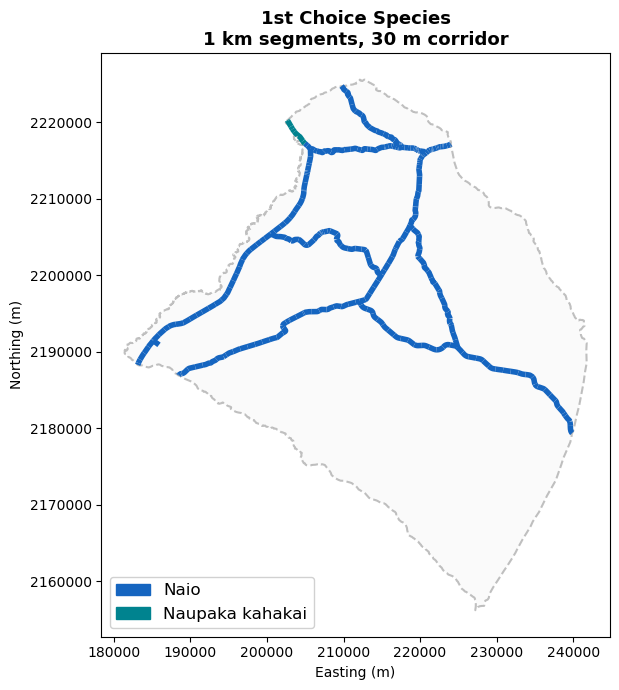

In [14]:
# Cell 8 - Plot Top Choice Species Map

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1.5, linestyle="--", alpha=0.3)

no_sp_mask = segments["choice_1_species"].isna()
if no_sp_mask.any():
    segments[no_sp_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

legend_handles = []
for species_name in SPECIES_FILES.keys():
    color = SPECIES_COLORS[species_name]
    mask = segments["choice_1_species"] == species_name
    if mask.any():
        segments[mask].plot(ax=ax, color=color, linewidth=4)
        legend_handles.append(mpatches.Patch(color=color, label=species_name))

if no_sp_mask.any():
    legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species"))

ax.set_title("1st Choice Species\n1 km segments, 30 m corridor",
             fontsize=13, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower left", fontsize=12, framealpha=0.9)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("1st_choice_species.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


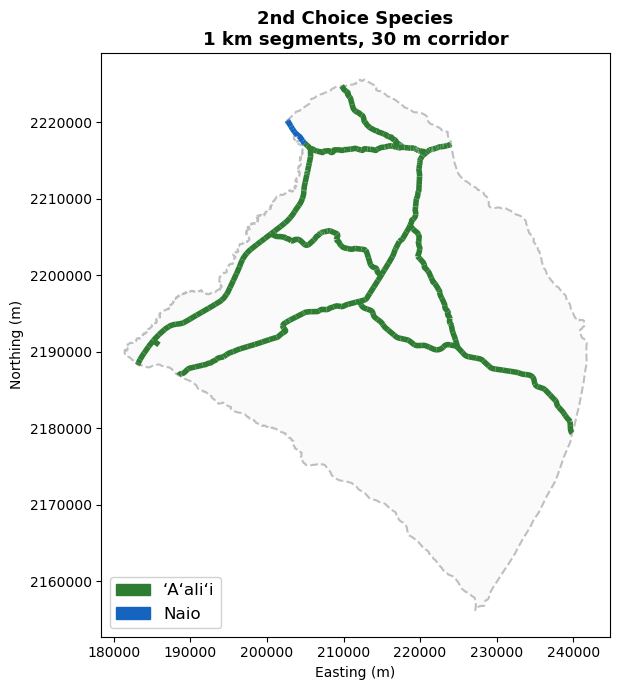

In [15]:
# Cell 9 - Plot Second Choice Species Map

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1.5, linestyle="--", alpha=0.3)

no_sp2_mask = segments["choice_2_species"].isna()
if no_sp2_mask.any():
    segments[no_sp2_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

legend_handles = []
for species_name in SPECIES_FILES.keys():
    color = SPECIES_COLORS[species_name]
    mask = segments["choice_2_species"] == species_name
    if mask.any():
        segments[mask].plot(ax=ax, color=color, linewidth=4)
        legend_handles.append(mpatches.Patch(color=color, label=species_name))

if no_sp2_mask.any():
    legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species / only 1 choice"))

ax.set_title("2nd Choice Species\n1 km segments, 30 m corridor",
             fontsize=13, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower left", fontsize=12, framealpha=0.9)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("2nd_choice_species.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


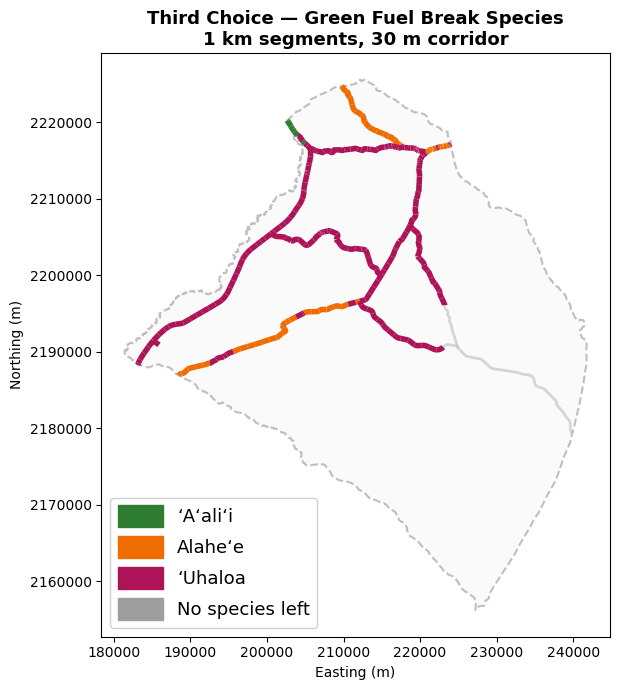

In [22]:
# Cell 10 - Plot Third Choice Species Map

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1.5, linestyle="--", alpha=0.3)

no_sp3_mask = segments["choice_3_species"].isna()
if no_sp3_mask.any():
    segments[no_sp3_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

legend_handles = []
for species_name in SPECIES_FILES.keys():
    color = SPECIES_COLORS[species_name]
    mask = segments["choice_3_species"] == species_name
    if mask.any():
        segments[mask].plot(ax=ax, color=color, linewidth=4)
        legend_handles.append(mpatches.Patch(color=color, label=species_name))

if no_sp3_mask.any():
    legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species left"))

ax.set_title("Third Choice — Green Fuel Break Species\n1 km segments, 30 m corridor",
             fontsize=13, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower left", fontsize=13, framealpha=0.9,
          markerscale=1.5, handlelength=2.5, handleheight=1.5)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
fig.savefig("map_choice_3.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.tight_layout()
plt.show()

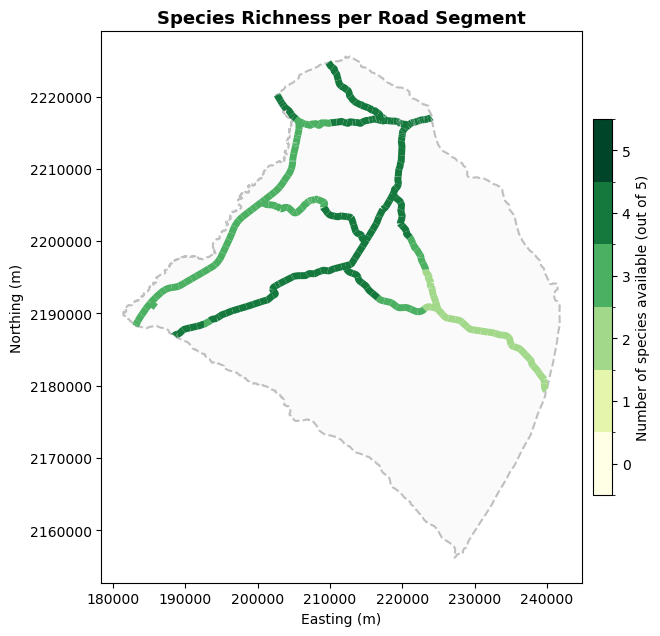

  2 species: 31 segments
  3 species: 89 segments
  4 species: 160 segments


In [16]:
# Cell 10 - Species Richness Map

from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

# Count how many of the top 5 species are available per segment
segments["n_species"] = segments["seg_id"].apply(
    lambda sid: len(results.get(sid, {})))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1.5, linestyle="--", alpha=0.3)

cmap = plt.cm.YlGn  # light yellow (0) to dark green (5)
bounds_vals = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
bnorm = BoundaryNorm(bounds_vals, cmap.N)

for _, row in segments.iterrows():
    n = row["n_species"]
    color = cmap(bnorm(n))
    geom = row.geometry
    parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
    for part in parts:
        xs, ys = part.xy
        ax.plot(xs, ys, color=color, linewidth=5, solid_capstyle="butt")

sm = ScalarMappable(cmap=cmap, norm=bnorm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=[0, 1, 2, 3, 4, 5], shrink=0.6, pad=0.02)
cbar.set_label("Number of species available (out of 5)", fontsize=10)

ax.set_title("Species Richness per Road Segment",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("species_richness.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Summary
for n in range(6):
    cnt = (segments["n_species"] == n).sum()
    if cnt > 0:
        print(f"  {n} species: {cnt} segments")

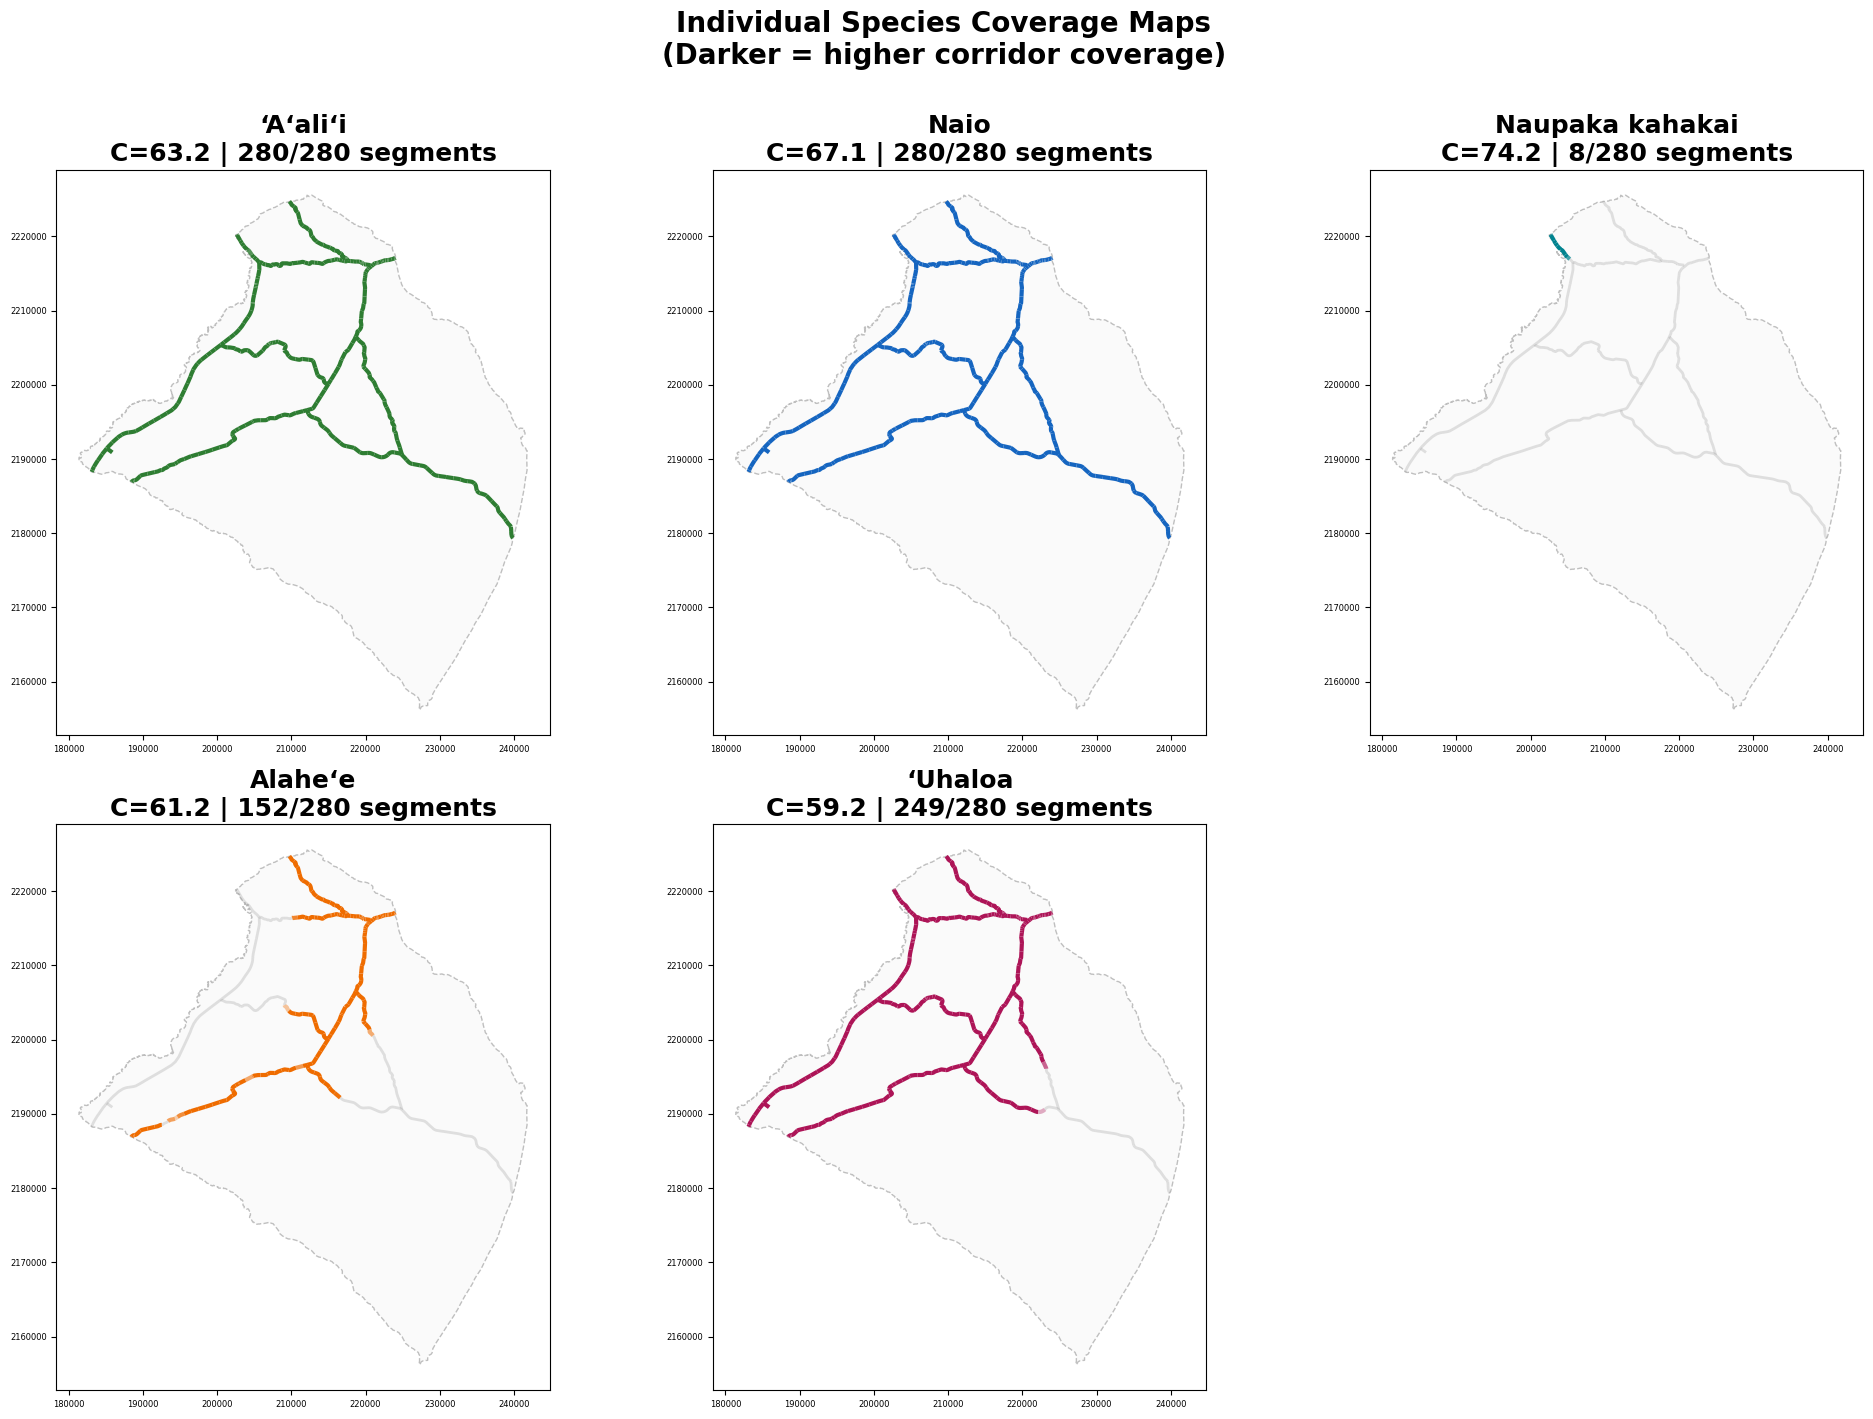

In [17]:
# Cell 11 - Individual Species Coverage Maps

from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, (species_name, shp_base) in enumerate(SPECIES_FILES.items()):
    ax = axes[idx]
    boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1, linestyle="--", alpha=0.3)

    # Get coverage for this species per segment
    coverages = []
    for _, row in segments.iterrows():
        sid = row["seg_id"]
        sp_info = results.get(sid, {}).get(species_name)
        coverages.append(sp_info["coverage"] if sp_info else 0)
    segments["_cov"] = coverages

    # Plot segments with no coverage
    no_cov = segments[segments["_cov"] == 0]
    if len(no_cov) > 0:
        no_cov.plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.3)

    # Plot segments with coverage, colored by coverage fraction
    has_cov = segments[segments["_cov"] > 0]
    if len(has_cov) > 0:
        color = SPECIES_COLORS[species_name]
        for _, row in has_cov.iterrows():
            cov = row["_cov"]
            alpha = 0.3 + 0.7 * cov  # scale alpha by coverage
            geom = row.geometry
            parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
            for part in parts:
                xs, ys = part.xy
                ax.plot(xs, ys, color=color, linewidth=3, alpha=alpha, solid_capstyle="butt")

    C = score_lookup.get(species_name, 0)
    n_present = (segments["_cov"] > 0).sum()
    ax.set_title(f"{species_name}\nC={C:.1f} | {n_present}/{len(segments)} segments",
                 fontsize=18, fontweight="bold")
    ax.set_aspect("equal")
    ax.ticklabel_format(style="plain")
    ax.tick_params(labelsize=6)

# Hide unused subplot (6th)
axes[5].set_visible(False)

segments.drop(columns=["_cov"], inplace=True)

plt.suptitle("Individual Species Coverage Maps\n(Darker = higher corridor coverage)",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("species_cover_maps.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [23]:
# Cell 12 - Output locations
import glob

for name in ["road_segments", "road_segments_scored"]:
    shp_files = glob.glob(f"{name}.*")
    print(f"{name}: {shp_files}")

print(f"\nFiles saved in: {os.getcwd()}")

road_segments: ['road_segments.zip', 'road_segments.prj', 'road_segments.shp', 'road_segments.cpg', 'road_segments.shx', 'road_segments.dbf']
road_segments_scored: ['road_segments_scored.dbf', 'road_segments_scored.shx', 'road_segments_scored.cpg', 'road_segments_scored.shp', 'road_segments_scored.prj', 'road_segments_scored.zip']

Files saved in: /Users/garyding/Desktop/gbf_top10
